<a href="https://colab.research.google.com/github/Ayesha-coder317/Portfolio/blob/Deep-Learning/DL_Portfolio_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support
)

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers


In [ ]:
data = fetch_covtype()
X = data.data
y = data.target  # labels are 1..7

print("X shape:", X.shape)   # (rows, features)
print("y shape:", y.shape)
print("Classes:", np.unique(y))


X shape: (581012, 54)
y shape: (581012,)
Classes: [1 2 3 4 5 6 7]


In [ ]:
# Convert labels from 1..7 to 0..6 for Keras
y_train0 = y_train - 1
y_val0   = y_val - 1
y_test0  = y_test - 1

print("Unique y_train0:", np.unique(y_train0))
print("Unique y_val0:", np.unique(y_val0))
print("Unique y_test0:", np.unique(y_test0))


Unique y_train0: [0 1 2 3 4 5 6]
Unique y_val0: [0 1 2 3 4 5 6]
Unique y_test0: [0 1 2 3 4 5 6]


In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (419781, 54) Val: (74079, 54) Test: (87152, 54)


In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit only on train to avoid leakage
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)


In [ ]:
def evaluate_model(y_true, y_pred, title="Model"):
    acc = accuracy_score(y_true, y_pred)

    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    print(f"\n===== {title} =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro    - Precision: {prec_macro:.4f}, Recall: {rec_macro:.4f}, F1: {f1_macro:.4f}")
    print(f"Weighted - Precision: {prec_w:.4f}, Recall: {rec_w:.4f}, F1: {f1_w:.4f}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion matrix:\n", cm)

    return cm


In [ ]:
def make_baseline_mlp(input_dim, num_classes=7):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

baseline = make_baseline_mlp(X_train_s.shape[1], 7)

baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,751 (61.53 KB)

 Trainable params: 15,751 (61.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_base = baseline.fit(
    X_train_s, y_train0,
    validation_data=(X_val_s, y_val0),
    epochs=20,
    batch_size=1024,
    verbose=1
)


Epoch 1/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6614 - loss: 0.8686 - val_accuracy: 0.7572 - val_loss: 0.5714
Epoch 2/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7646 - loss: 0.5532 - val_accuracy: 0.7798 - val_loss: 0.5152
Epoch 3/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7834 - loss: 0.5042 - val_accuracy: 0.7919 - val_loss: 0.4857
Epoch 4/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7976 - loss: 0.4724 - val_accuracy: 0.8048 - val_loss: 0.4584
Epoch 5/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8105 - loss: 0.4457 - val_accuracy: 0.8151 - val_loss: 0.4376
Epoch 6/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8219 - loss: 0.4254 - val_accuracy: 0.8244 - val_loss: 0.4203
Epoch 7/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8295 - loss: 0.4090 - val_accuracy: 0.8346 - val_loss: 0.4028
Epoch 8/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8354 - loss: 0.3948 - val_accuracy: 0.

In [ ]:
y_pred_base0 = np.argmax(baseline.predict(X_test_s, verbose=0), axis=1)
cm_base = evaluate_model(y_test0, y_pred_base0, "Baseline MLP (Test)")


In [ ]:
def make_improved_mlp(input_dim, num_classes=7, act="leakyrelu", l2=1e-4, drop=0.3):
    def apply_activation(x):
        if act.lower() == "relu":
            return layers.Activation("relu")(x)
        if act.lower() == "selu":
            return layers.Activation("selu")(x)
        # leakyrelu default (use negative_slope instead of alpha to avoid warning)
        return layers.LeakyReLU(negative_slope=0.1)(x)

    reg = regularizers.l2(l2)

    inputs = layers.Input(shape=(input_dim,))

    x = layers.Dense(512, kernel_regularizer=reg)(inputs)
    x = layers.BatchNormalization()(x)
    x = apply_activation(x)
    x = layers.Dropout(drop)(x)

    x = layers.Dense(256, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = apply_activation(x)
    x = layers.Dropout(drop)(x)

    x = layers.Dense(128, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = apply_activation(x)
    x = layers.Dropout(drop)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model



In [ ]:
improved = make_improved_mlp(
    input_dim=X_train_s.shape[1],
    num_classes=7,
    act="leakyrelu",
    l2=1e-4,
    drop=0.3
)

improved.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved.summary()


In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )
]

history_imp = improved.fit(
    X_train_s, y_train0,
    validation_data=(X_val_s, y_val0),
    epochs=50,
    batch_size=1024,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.6816 - loss: 0.8920 - val_accuracy: 0.7713 - val_loss: 0.5825 - learning_rate: 0.0020
Epoch 2/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.7649 - loss: 0.5953 - val_accuracy: 0.7977 - val_loss: 0.5159 - learning_rate: 0.0020
Epoch 3/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.7843 - loss: 0.5460 - val_accuracy: 0.8134 - val_loss: 0.4855 - learning_rate: 0.0020
Epoch 4/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.7956 - loss: 0.5219 - val_accuracy: 0.8247 - val_loss: 0.4618 - learning_rate: 0.0020
Epoch 5/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.8056 - loss: 0.5025 - val_accuracy: 0.8315 - val_loss: 0.4480 - learning_rate: 0.0020
Epoch 6/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.8103 - loss: 0.4961 - val_accuracy: 0.8364 - val_loss: 0.4368 - learning_rate: 0.0020
Epoch 7/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.8155 - l

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title="Training Curves"):
    hist = history.history

    # Accuracy curve
    plt.figure()
    plt.plot(hist.get("accuracy", []), label="train_acc")
    plt.plot(hist.get("val_accuracy", []), label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # Loss curve
    plt.figure()
    plt.plot(hist.get("loss", []), label="train_loss")
    plt.plot(hist.get("val_loss", []), label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


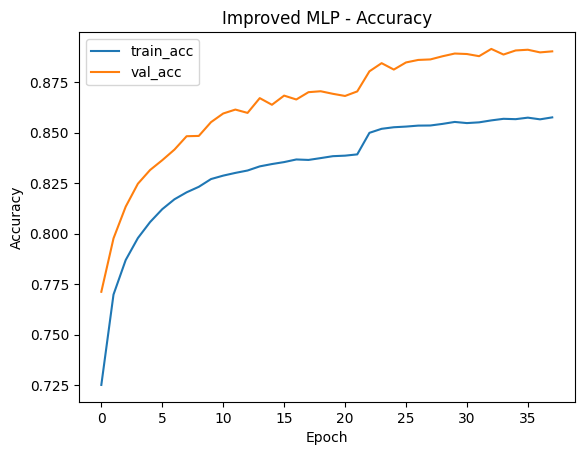

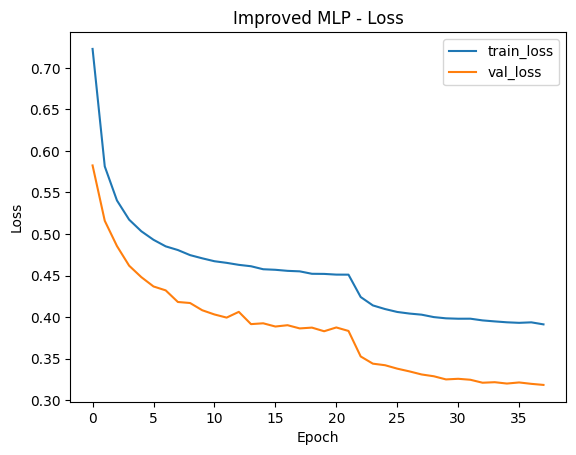

In [ ]:
plot_history(history_imp, "Improved MLP")


In [ ]:
# Predict class indices (0..6)
y_pred_imp0 = np.argmax(improved.predict(X_test_s, verbose=0), axis=1)

# Evaluate (macro + weighted + confusion matrix + report)
cm_imp = evaluate_model(y_test0, y_pred_imp0, "Improved MLP (Test)")



===== Improved MLP (Test) =====
Accuracy: 0.8911
Macro    - Precision: 0.8576, Recall: 0.8182, F1: 0.8359
Weighted - Precision: 0.8912, Recall: 0.8911, F1: 0.8904

Classification report:
              precision    recall  f1-score   support

           0     0.9093    0.8583    0.8831     31776
           1     0.8884    0.9310    0.9092     42495
           2     0.8765    0.8997    0.8879      5363
           3     0.8490    0.7233    0.7811       412
           4     0.7773    0.6348    0.6989      1424
           5     0.7986    0.7962    0.7974      2605
           6     0.9040    0.8843    0.8940      3077

    accuracy                         0.8911     87152
   macro avg     0.8576    0.8182    0.8359     87152
weighted avg     0.8912    0.8911    0.8904     87152

Confusion matrix:
 [[27273  4203     2     0    30    12   256]
 [ 2359 39563   167     0   229   144    33]
 [    5   162  4825    30     0   341     0]
 [    0     0    93   298     0    21     0]
 [   27   437   

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Random Forest does NOT need scaling, so use X_train / X_test (unscaled)
rf.fit(X_train, y_train0)     # keep labels 0..6 for consistent evaluation
y_pred_rf0 = rf.predict(X_test)

cm_rf = evaluate_model(y_test0, y_pred_rf0, "Random Forest (Test)")



===== Random Forest (Test) =====
Accuracy: 0.9526
Macro    - Precision: 0.9454, Recall: 0.9028, F1: 0.9222
Weighted - Precision: 0.9528, Recall: 0.9526, F1: 0.9523

Classification report:
              precision    recall  f1-score   support

           0     0.9640    0.9393    0.9515     31776
           1     0.9469    0.9734    0.9600     42495
           2     0.9346    0.9623    0.9483      5363
           3     0.9143    0.8544    0.8833       412
           4     0.9541    0.7591    0.8455      1424
           5     0.9334    0.8871    0.9097      2605
           6     0.9706    0.9441    0.9572      3077

    accuracy                         0.9526     87152
   macro avg     0.9454    0.9028    0.9222     87152
weighted avg     0.9528    0.9526    0.9523     87152

Confusion matrix:
 [[29847  1846     1     0     6     3    73]
 [  935 41363    89     0    39    54    15]
 [    1    86  5161    19     5    91     0]
 [    0     0    49   352     0    11     0]
 [   21   300  

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def get_scores(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    _, _, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    _, _, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return acc, f1_macro, f1_weighted

# Improved MLP scores
acc_imp, f1m_imp, f1w_imp = get_scores(y_test0, y_pred_imp0)

# RF scores
acc_rf, f1m_rf, f1w_rf = get_scores(y_test0, y_pred_rf0)

results = pd.DataFrame({
    "Model": ["Improved MLP", "Random Forest"],
    "Accuracy": [acc_imp, acc_rf],
    "F1 Macro": [f1m_imp, f1m_rf],
    "F1 Weighted": [f1w_imp, f1w_rf]
})

results


,Model,Accuracy,F1 Macro,F1 Weighted
0,Improved MLP,0.908206,0.867908,0.907910
1,Random Forest,0.952589,0.922199,0.952318


Why Random Forest often outperforms MLP on tabular data:

Tree ensembles naturally capture non-linear interactions between features without needing heavy feature engineering.

They work well even when features have different scales and distributions (scaling not required).

They are usually more sample-efficient and need less hyperparameter tuning than neural networks for structured/tabular datasets.

In our experiment, Random Forest achieved stronger overall generalization compared to the MLP, as seen in test metrics and confusion matrix patterns.
